# Predicting category switching

## 1. Project overview

### Business problem
An e-commerce website could use browsing behavior to decide whether to keep showing
products from the current category or introduce products from other categories.
This notebook predicts category switching. It does not build a complete recommendation system.

### Research question
> Can users' current and historical browsing behavior help predict whether they will switch to another product category on their next click?

- **RQ1:** How well can current browsing information predict category switching?
- **RQ2:** Does adding browsing history improve switch prediction?

### Target
> Given that there is another click in the session, will the next click remain in the current category or switch to another category?

- `switch_category = 0`: the next category is the same (**Stay**).
- `switch_category = 1`: the next category is different (**Switch**).

The model does not predict whether a user leaves the website or ends the session.

**Switch = 1 is the positive class and the business-interest class.**
Features are the information available to the model at the current click.
We compare **Current** with **Current + History**, using the same observations and session split.

Run all cells in order from the project folder, using the project's Python environment
and `requirements.txt`. Only the original CSV is needed as an input.

## 2. Import libraries
Pandas and NumPy prepare the data. Matplotlib and Seaborn draw the plots.
Scikit-learn prepares the model inputs, trains the models, and evaluates predictions.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 14)

## 3. Load and understand the data

The local `e-shop clothing 2008 data description.txt` describes these variables:

| Variable | Meaning |
| --- | --- |
| `session ID` | A browsing session, not a known customer identity |
| `order` | Click sequence within that session |
| `page 1 (main category)` | 1 = Trousers, 2 = Skirts, 3 = Blouses, 4 = Sale |
| `page 2 (clothing model)` | A product code |
| `price` | Current product price in US dollars |
| `colour` | Product colour code |
| `location` | Product photo position in one of six screen areas |
| `model photography` | Front view or profile view |
| `page` | Catalogue page number, from 1 to 5 |
| `price 2` | Whether price is above the category average |

The data cover April to August 2008. A click records browsing, not a purchase.

In [39]:
df = pd.read_csv("e-shop clothing 2008.csv")
display(df.head())
print("Rows and columns:", df.shape)
print("Column names:", df.columns.tolist())

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,4,1,1,29,1,1,A13,1,5,1,28,2,1
1,2008,4,1,2,29,1,1,A16,1,6,1,33,2,1
2,2008,4,1,3,29,1,2,B4,10,2,1,52,1,1
3,2008,4,1,4,29,1,2,B17,6,6,2,38,2,1
4,2008,4,1,5,29,1,2,B8,4,3,2,52,1,1


Rows and columns: (165474, 14)
Column names: ['year', 'month', 'day', 'order', 'country', 'session ID', 'page 1 (main category)', 'page 2 (clothing model)', 'colour', 'location', 'model photography', 'price', 'price 2', 'page']


In [40]:
df.info()
display(df.isna().sum().rename("Missing values").to_frame())
print("Duplicate rows:", df.duplicated().sum())
print("Sessions:", df["session ID"].nunique())
print("Clothing models:", df["page 2 (clothing model)"].nunique())

assert not df.isna().any().any()
assert not df.duplicated().any()
assert not df.duplicated(["session ID", "order"]).any()
assert set(df["page 1 (main category)"]) == {1, 2, 3, 4}

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   year                     165474 non-null  int64 
 1   month                    165474 non-null  int64 
 2   day                      165474 non-null  int64 
 3   order                    165474 non-null  int64 
 4   country                  165474 non-null  int64 
 5   session ID               165474 non-null  int64 
 6   page 1 (main category)   165474 non-null  int64 
 7   page 2 (clothing model)  165474 non-null  object
 8   colour                   165474 non-null  int64 
 9   location                 165474 non-null  int64 
 10  model photography        165474 non-null  int64 
 11  price                    165474 non-null  int64 
 12  price 2                  165474 non-null  int64 
 13  page                     165474 non-null  int64 
dtypes: int64(13), object

,Missing values
year,0
month,0
day,0
order,0
country,0
session ID,0
page 1 (main category),0
page 2 (clothing model),0
colour,0
location,0


Duplicate rows: 0
Sessions: 24026
Clothing models: 217


The data contain 165,474 clicks in 24,026 sessions,
with 217 clothing models. There are no missing values, duplicate rows, or duplicate
session-position pairs. We can construct click sequences without deleting or filling raw observations.

## 4. Sort clicks and create the target

Sort before using `shift()` or `cumcount()`. They follow row order, so clicks must
be in sequence within each session. `shift(-1)` reads the next click to create the
target only. That future category must never be a model input.

In [41]:
df = df.sort_values(["session ID", "order"]).copy()
df["next_category"] = (
    df.groupby("session ID")["page 1 (main category)"].shift(-1)
)
df["switch_category"] = (
    df["next_category"] != df["page 1 (main category)"]
).astype(int)

The comparison returns 1 when `next_category` is missing, but this is not a valid label.
We remove those final clicks after creating history. First clicks remain when they have
a next click; single-click sessions cannot contribute an observation.

## 5. Create three history features

- `prev_category`: previous category; 0 explicitly means no previous click.
- `same_category_prev`: -1 = no previous click, 0 = different, 1 = same.
- `category_visit_count`: visits to the current category **before** this click.

These features use past clicks within the same session. The current category is
already known when predicting the next click.

In [42]:
df["prev_category"] = (
    df.groupby("session ID")["page 1 (main category)"].shift(1)
)
df["prev_category"] = df["prev_category"].fillna(0).astype(int)
df["same_category_prev"] = np.where(
    df["prev_category"] == 0,
    -1,
    (df["prev_category"] == df["page 1 (main category)"]).astype(int)
)
df["category_visit_count"] = (
    df.groupby(["session ID", "page 1 (main category)"]).cumcount()
)

`cumcount()` starts at zero. It excludes the current click and all later clicks.
A total session count would include future visits and cause data leakage,
which means giving a model information it would not have at prediction time.

## 6. Keep rows with a valid next click
Retain first and middle clicks when a next click exists. Remove only final clicks.
The following two sessions let us check the features against the original sequence.

In [43]:
df_model = df[df["next_category"].notna()].copy()
print("Raw clicks:", len(df))
print("Removed final clicks:", len(df) - len(df_model))
print("Rows with a target:", len(df_model))
print("Retained first clicks:", df_model["prev_category"].eq(0).sum())

example_columns = [
    "session ID", "order", "page 1 (main category)", "prev_category",
    "same_category_prev", "category_visit_count", "next_category", "switch_category"
]
display(df_model.loc[df_model["session ID"].isin([1, 2]), example_columns])

Raw clicks: 165474
Removed final clicks: 24026
Rows with a target: 141448
Retained first clicks: 18984


,session ID,order,page 1 (main category),prev_category,same_category_prev,category_visit_count,next_category,switch_category
0,1,1,1,0,-1,0,1.0,0
1,1,2,1,1,1,1,2.0,1
2,1,3,2,1,0,0,2.0,0
3,1,4,2,2,1,1,2.0,0
4,1,5,2,2,1,2,3.0,1
5,1,6,3,2,0,0,3.0,0
6,1,7,3,3,1,1,4.0,1
7,1,8,4,3,0,0,4.0,0
9,2,1,2,0,-1,0,2.0,0
10,2,2,2,2,1,1,2.0,0


In session 1, click 1 has no previous category and zero earlier visits. Click 2 has
one earlier visit to Trousers and switches next to Skirts. On click 3, the earlier
visit count for Skirts is zero. The removed final click still supplies the next
category for the preceding row.

In [44]:
first_rows = df.groupby("session ID").head(1)
last_rows = df.groupby("session ID").tail(1)
valid_first_rows = first_rows[first_rows["next_category"].notna()]

assert df_model.index.intersection(last_rows.index).empty
assert valid_first_rows.index.isin(df_model.index).all()
print("Final clicks removed; first clicks with a next click retained.")
print("Excluded single-click sessions:", first_rows["next_category"].isna().sum())

Final clicks removed; first clicks with a next click retained.
Excluded single-click sessions: 5042


## 7. Split by session
Use one 80/20 session split for all models, before exploring training data.
A row-level split could put related clicks in both sets and inflate test performance.
This evaluates unseen sessions, not necessarily unseen people. No cross-validation is used.

In [45]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_index, test_index = next(
    splitter.split(df_model, groups=df_model["session ID"])
)
train_df = df_model.iloc[train_index].copy()
test_df = df_model.iloc[test_index].copy()
train_sessions = train_df["session ID"].unique()
test_sessions = test_df["session ID"].unique()

assert set(train_sessions).isdisjoint(set(test_sessions))
print("Train rows / sessions:", len(train_df), len(train_sessions))
print("Test rows / sessions:", len(test_df), len(test_sessions))
print("Overlapping sessions:", len(set(train_sessions) & set(test_sessions)))

Train rows / sessions: 112491 15187
Test rows / sessions: 28957 3797
Overlapping sessions: 0


## 8. Explore category switching
All eight plots use **training clicks with an observed next click**. Tables include
counts because groups have different sizes. Longer sessions contribute more clicks;
the observed associations do not establish causation.

### How common is switching?

,Count,Share (%)
switch_category,,
Stay,91257,81.12
Switch,21234,18.88


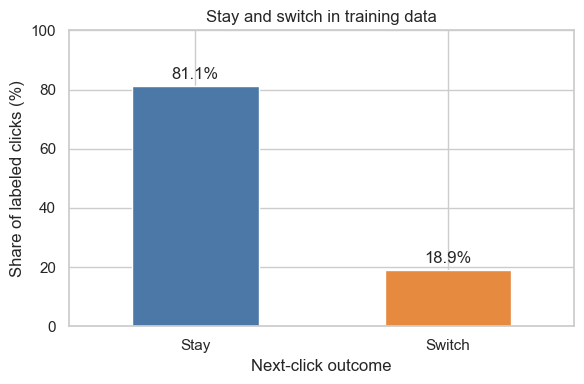

In [46]:
target_counts = train_df["switch_category"].value_counts().reindex([0, 1])
target_summary = pd.DataFrame({
    "Count": target_counts,
    "Share (%)": 100 * target_counts / target_counts.sum()
}).rename(index={0: "Stay", 1: "Switch"})
display(target_summary.round(2))
ax = target_summary["Share (%)"].plot.bar(
    rot=0, color=["#4c78a8", "#e68a3f"], figsize=(6, 4)
)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
ax.set(title="Stay and switch in training data", xlabel="Next-click outcome",
       ylabel="Share of labeled clicks (%)", ylim=(0, 100))
plt.tight_layout()
plt.show()

Switch represents 18.88% of training clicks. Always predicting Stay can therefore
look accurate while missing every switch. We need Switch precision, recall, and F1
to evaluate detection of the minority class.

### Are some current categories associated with more switching?

,Clicks,Switch rate
page 1 (main category),,
Trousers,34038,0.199
Skirts,25878,0.207
Blouses,26264,0.204
Sale,26311,0.142


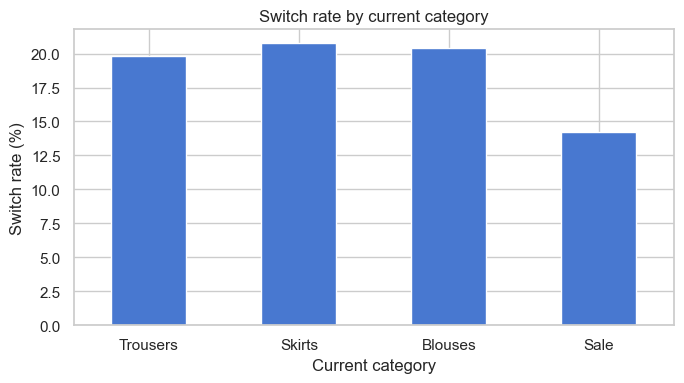

In [47]:
category_names = {1: "Trousers", 2: "Skirts", 3: "Blouses", 4: "Sale"}
category_rates = train_df.groupby("page 1 (main category)")["switch_category"].agg(
    ["size", "mean"]
).rename(index=category_names, columns={"size": "Clicks", "mean": "Switch rate"})
display(category_rates.round(3))
ax = (100 * category_rates["Switch rate"]).plot.bar(rot=0, figsize=(7, 4))
ax.set(title="Switch rate by current category", xlabel="Current category",
       ylabel="Switch rate (%)")
plt.tight_layout()
plt.show()

Sale has a switch rate of 14.2%,
compared with 20.7% for Skirts. This variation supports
retaining current category. It describes an association, not an effect caused by the category.

### Does switching vary with browsing position?

,Clicks,Switch rate
order,,
1,15187,0.219
2-3,22974,0.218
4-6,22686,0.211
7-10,18046,0.187
11+,33598,0.141


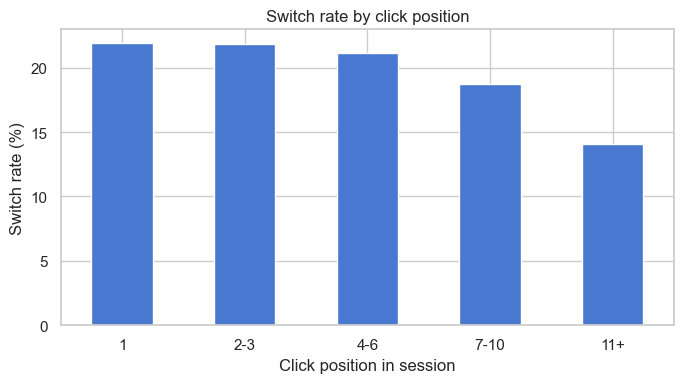

In [48]:
order_groups = pd.cut(
    train_df["order"], bins=[0, 1, 3, 6, 10, np.inf],
    labels=["1", "2-3", "4-6", "7-10", "11+"]
)
order_rates = train_df.groupby(order_groups, observed=True)["switch_category"].agg(
    ["size", "mean"]
)
display(order_rates.rename(columns={"size": "Clicks", "mean": "Switch rate"}).round(3))
ax = (100 * order_rates["mean"]).plot.bar(rot=0, figsize=(7, 4))
ax.set(title="Switch rate by click position", xlabel="Click position in session",
       ylabel="Switch rate (%)")
plt.tight_layout()
plt.show()

The switch rate falls from 21.9% at the first click
to 14.1% at positions 11 and later. Retain `order` as current context.
This comparison also reflects which sessions continue long enough to reach later positions.

### Does recent category consistency relate to switching?

,Clicks,Switch rate
same_category_prev,,
No previous click,15187,0.219
Previous different,16982,0.225
Previous same,80322,0.175


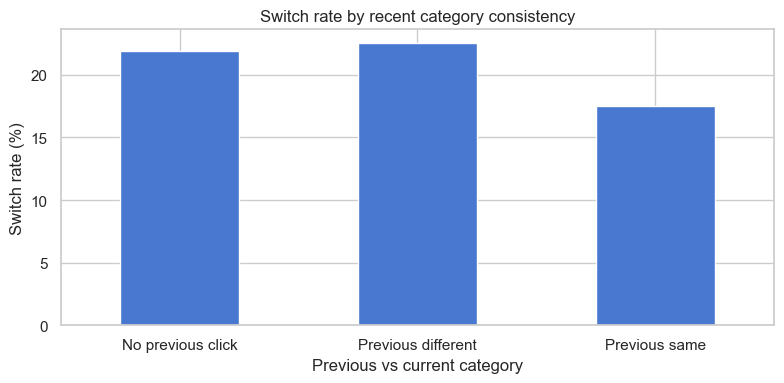

In [49]:
history_labels = {-1: "No previous click", 0: "Previous different", 1: "Previous same"}
consistency_rates = train_df.groupby("same_category_prev")["switch_category"].agg(
    ["size", "mean"]
).rename(index=history_labels)
display(consistency_rates.rename(columns={"size": "Clicks", "mean": "Switch rate"}).round(3))
ax = (100 * consistency_rates["mean"]).plot.bar(rot=0, figsize=(8, 4))
ax.set(title="Switch rate by recent category consistency", xlabel="Previous vs current category",
       ylabel="Switch rate (%)")
plt.tight_layout()
plt.show()

Switching is 22.5% after a different category, 17.5% after the same category, and
21.9% on first clicks. Recent consistency may help; the model comparison will test
whether it adds value beyond current information.

### Does repeated interest in the current category relate to switching?

,Clicks,Switch rate
category_visit_count,,
0,28486,0.215
1,19755,0.204
2,14110,0.199
3-4,17956,0.192
5+,32184,0.149


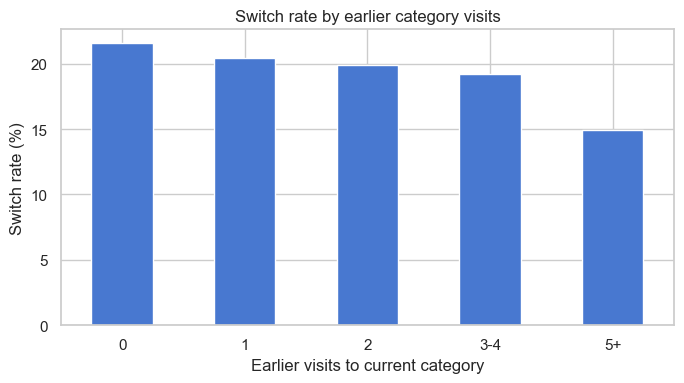

In [50]:
visit_groups = pd.cut(
    train_df["category_visit_count"], bins=[-1, 0, 1, 2, 4, np.inf],
    labels=["0", "1", "2", "3-4", "5+"]
)
visit_rates = train_df.groupby(visit_groups, observed=True)["switch_category"].agg(
    ["size", "mean"]
)
display(visit_rates.rename(columns={"size": "Clicks", "mean": "Switch rate"}).round(3))
ax = (100 * visit_rates["mean"]).plot.bar(rot=0, figsize=(7, 4))
ax.set(title="Switch rate by earlier category visits", xlabel="Earlier visits to current category",
       ylabel="Switch rate (%)")
plt.tight_layout()
plt.show()

Switching falls from 21.5% with no earlier category visit to 14.9% with five or more.
Repeated interest may help prediction, but it overlaps with session position.

### Do specific previous-to-current transitions differ?

Current category,Trousers,Skirts,Blouses,Sale
Previous category,,,,
Trousers,24312,2102,2099,1282
Skirts,1297,17700,1997,1026
Blouses,1397,1106,18536,1724
Sale,1008,933,1011,19774


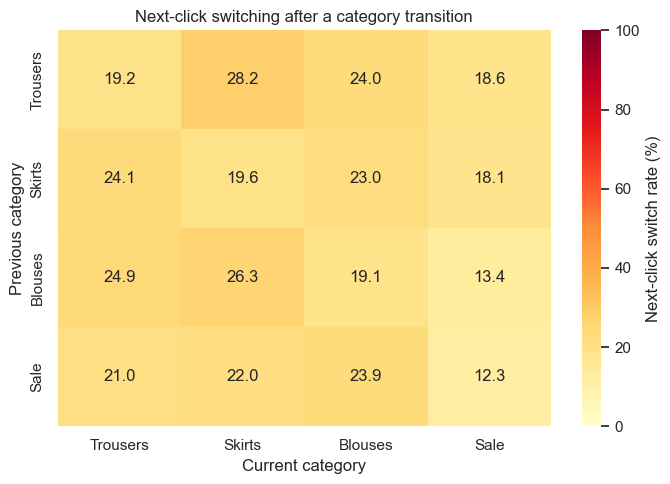

In [51]:
past_clicks = train_df[train_df["prev_category"] != 0]
transition_rates = past_clicks.pivot_table(
    index="prev_category", columns="page 1 (main category)",
    values="switch_category", aggfunc="mean"
).rename(index=category_names, columns=category_names)
transition_counts = past_clicks.pivot_table(
    index="prev_category", columns="page 1 (main category)",
    values="switch_category", aggfunc="size"
).rename(index=category_names, columns=category_names)
display(transition_counts.rename_axis(index="Previous category", columns="Current category"))
plt.figure(figsize=(7, 5))
sns.heatmap(100 * transition_rates, annot=True, fmt=".1f", cmap="YlOrRd",
            vmin=0, vmax=100, cbar_kws={"label": "Next-click switch rate (%)"})
plt.title("Next-click switching after a category transition")
plt.xlabel("Current category")
plt.ylabel("Previous category")
plt.tight_layout()
plt.show()

For current Skirts, the next-click switch rate is 28.2% after Trousers and 22.0%
after Sale. This supports testing `prev_category` alongside recent consistency.
First clicks are excluded; each transition has at least 933 observations.

### Are current prices different for stay and switch observations?

,median,mean
switch_category,,
Stay,43.0,43.65
Switch,43.0,44.25


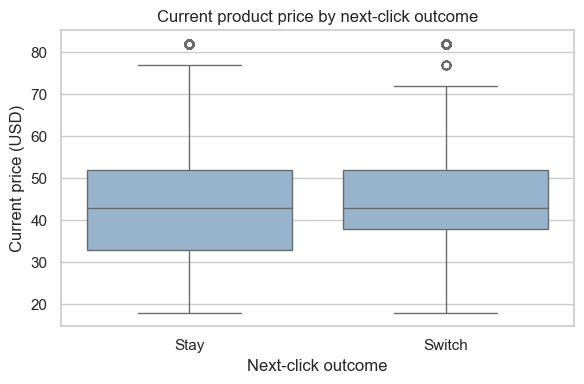

In [52]:
price_summary = train_df.groupby("switch_category")["price"].agg(["median", "mean"])
display(price_summary.rename(index={0: "Stay", 1: "Switch"}).round(2))
plt.figure(figsize=(6, 4))
sns.boxplot(data=train_df, x="switch_category", y="price", order=[0, 1], color="#8fb4d6")
plt.xticks([0, 1], ["Stay", "Switch"])
plt.title("Current product price by next-click outcome")
plt.xlabel("Next-click outcome")
plt.ylabel("Current price (USD)")
plt.tight_layout()
plt.show()

Both groups have a median price of $43, and their distributions overlap strongly.
Price alone does not clearly separate Stay and Switch. Keep it in the specified
current feature set to evaluate it alongside other inputs.

### Does switching vary by catalogue page?

,Clicks,Switch rate
page,,
1,63833,0.178
2,28181,0.179
3,13014,0.219
4,5809,0.255
5,1654,0.282


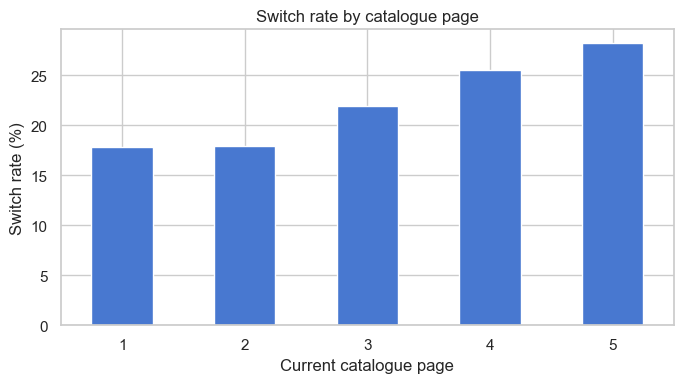

In [53]:
page_rates = train_df.groupby("page")["switch_category"].agg(["size", "mean"])
display(page_rates.rename(columns={"size": "Clicks", "mean": "Switch rate"}).round(3))
ax = (100 * page_rates["mean"]).plot.bar(rot=0, figsize=(7, 4))
ax.set(title="Switch rate by catalogue page", xlabel="Current catalogue page",
       ylabel="Switch rate (%)")
plt.tight_layout()
plt.show()

The switch rate rises from 17.8% on page 1 to
28.2% on page 5. Page 5 has only 1,654 observations,
compared with 63,833 on page 1. Retain catalogue page, while recognizing
that these pages may contain different categories and products.

## 9. Define two feature sets

Experiment A uses Current information. Experiment B adds exactly three history
features. Plot-only groups are not model inputs.

In [54]:
current_features = [
    "page 1 (main category)", "order", "price", "colour",
    "location", "model photography", "page"
]
current_history_features = current_features + [
    "prev_category", "same_category_prev", "category_visit_count"
]

current_categorical = [
    "page 1 (main category)", "colour", "location", "model photography"
]
current_numerical = ["order", "price", "page"]
history_categorical = current_categorical + ["prev_category", "same_category_prev"]
history_numerical = current_numerical + ["category_visit_count"]

Treat category codes as categories, including the three states of `same_category_prev`.
Treat `order`, `price`, `page`, and the visit count as numerical.

| Excluded column | Reason |
| --- | --- |
| `year` | Constant |
| `month`, `day` | Outside this version's behavioral hypothesis |
| `country` | Outside the specified current browsing feature set |
| `session ID` | Identifier used for grouping only |
| `page 2 (clothing model)` | Many product IDs, overlapping with product attributes |
| `price 2` | Price comparison with the category average |
| `next_category` | Future information used to create the target |
| `switch_category` | The target itself |

In [55]:
X_train_current = train_df[current_features]
X_test_current = test_df[current_features]
X_train_history = train_df[current_history_features]
X_test_history = test_df[current_history_features]
y_train = train_df["switch_category"]
y_test = test_df["switch_category"]

assert X_train_current.index.equals(X_train_history.index)
assert X_test_current.index.equals(X_test_history.index)
assert set(current_history_features) == set(history_categorical + history_numerical)
assert not {"next_category", "switch_category", "session ID"}.intersection(current_history_features)
print("Current features:", len(current_features))
print("Current + history features:", len(current_history_features))

Current features: 7
Current + history features: 10


## 10. Preprocessing and evaluation
One-hot encoding creates yes/no columns for categories. Each pipeline fits its encoder
on training data only. Numerical inputs are scaled for Logistic Regression; trees
use their original values. First-click history already has explicit no-history states.

Because **Switch = 1** is the minority and business-interest class, accuracy alone
can be misleading. **Switch F1 is the primary metric.**

### Key metrics
- **Switch precision:** when the model predicts Switch, how often it is correct.
- **Switch recall:** among actual switches, the share detected.
- **Switch F1:** balances precision and recall; low if either is low.

We also report accuracy (overall correctness), Macro F1 (equal average of both class
F1 scores), and ROC-AUC (how well scores rank Switch above Stay; 0.5 is chance ranking).
When no switches are predicted, undefined precision is reported as zero.

Model settings stay fixed. The small helper below only calculates metrics;
training remains explicit.

In [56]:
def evaluate(name, features, y_true, y_pred, y_score):
    return {
        "Model": name,
        "Features": features,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Switch precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Switch recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Switch F1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score)
    }

## 11. Always-stay baseline
Predict 0 for every test click. This gives us a simple reference before training models.
A constant score has ROC-AUC 0.5 because it cannot rank clicks.

In [57]:
stay_pred = np.zeros(len(y_test), dtype=int)
stay_result = evaluate("Always stay", "None", y_test, stay_pred, stay_pred)
results = [stay_result]
display(pd.DataFrame([stay_result]).round(4))

,Model,Features,Accuracy,Switch precision,Switch recall,Switch F1,Macro F1,ROC-AUC
0,Always stay,None,0.8173,0.0,0.0,0.0,0.4497,0.5


Always Stay achieves 81.73% accuracy but **Switch recall = 0
and Switch F1 = 0**. It misses all 5,291 actual switches. The high accuracy reflects
the majority Stay class, not useful switch detection.

## 12. Logistic Regression with current information

### Normal Logistic Regression
Start without class weighting. The pipeline scales numerical inputs and encodes
categorical inputs using only the training set.

In [58]:
lr_preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), current_categorical),
    ("num", StandardScaler(), current_numerical)
])
lr = Pipeline([
    ("preprocess", lr_preprocess),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
lr.fit(X_train_current, y_train)
lr_pred = lr.predict(X_test_current)
lr_score = lr.predict_proba(X_test_current)[:, 1]

In [59]:
lr_result = evaluate("Logistic Regression", "Current", y_test, lr_pred, lr_score)
results.append(lr_result)
display(pd.DataFrame([lr_result]).round(4))
print(classification_report(y_test, lr_pred, target_names=["Stay", "Switch"], zero_division=0))

,Model,Features,Accuracy,Switch precision,Switch recall,Switch F1,Macro F1,ROC-AUC
0,Logistic Regression,Current,0.8173,0.0,0.0,0.0,0.4497,0.6159


              precision    recall  f1-score   support

        Stay       0.82      1.00      0.90     23666
      Switch       0.00      0.00      0.00      5291

    accuracy                           0.82     28957
   macro avg       0.41      0.50      0.45     28957
weighted avg       0.67      0.82      0.74     28957



At its default threshold, normal Logistic Regression predicts Stay for every
test click. Accuracy is 81.73%, while Switch F1 is 0.0000.
ROC-AUC is 0.6159, so its scores contain some ranking information even though
the class predictions detect no switches. We next test class weighting.

### Balanced Logistic Regression
`class_weight="balanced"` gives minority-class errors more influence during training.
All other settings, features, and observations stay the same.

In [60]:
balanced_preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), current_categorical),
    ("num", StandardScaler(), current_numerical)
])
balanced_lr = Pipeline([
    ("preprocess", balanced_preprocess),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])
balanced_lr.fit(X_train_current, y_train)
balanced_pred = balanced_lr.predict(X_test_current)
balanced_score = balanced_lr.predict_proba(X_test_current)[:, 1]

In [61]:
balanced_result = evaluate(
    "Balanced Logistic Regression", "Current", y_test, balanced_pred, balanced_score
)
results.append(balanced_result)
display(pd.DataFrame([lr_result, balanced_result]).round(4))

,Model,Features,Accuracy,Switch precision,Switch recall,Switch F1,Macro F1,ROC-AUC
0,Logistic Regression,Current,0.8173,0.0000,0.0000,0.0000,0.4497,0.6159
1,Balanced Logistic Regression,Current,0.5664,0.2324,0.5961,0.3344,0.5064,0.6162


Balancing raises Switch recall from 0.00% to
59.61% and Switch F1 from 0.0000 to 0.3344.
Accuracy falls to 56.64%, and Switch precision is only 23.24%.
The model finds more switches but creates many false alerts. The lower accuracy does not
make it worse on our main metric.

## 13. Does history improve Logistic Regression?
Keep the balanced Logistic Regression and session split unchanged. Add only the
three history features. This is the first controlled comparison for RQ2.

In [62]:
history_preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), history_categorical),
    ("num", StandardScaler(), history_numerical)
])
history_lr = Pipeline([
    ("preprocess", history_preprocess),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])
history_lr.fit(X_train_history, y_train)
history_pred = history_lr.predict(X_test_history)
history_score = history_lr.predict_proba(X_test_history)[:, 1]

In [63]:
history_result = evaluate(
    "Balanced Logistic + History", "Current + History", y_test, history_pred, history_score
)
results.append(history_result)
display(pd.DataFrame([balanced_result, history_result]).round(4))
history_f1_change = history_result["Switch F1"] - balanced_result["Switch F1"]
print(f"Switch F1 change from history: {100 * history_f1_change:+.2f} percentage points")

,Model,Features,Accuracy,Switch precision,Switch recall,Switch F1,Macro F1,ROC-AUC
0,Balanced Logistic Regression,Current,0.5664,0.2324,0.5961,0.3344,0.5064,0.6162
1,Balanced Logistic + History,Current + History,0.5621,0.2335,0.6116,0.3379,0.5054,0.6242


Switch F1 change from history: +0.35 percentage points


Adding history raises Switch F1 from 0.3344 to
0.3379, only 0.35 percentage points.
Recall rises from 59.61% to 61.16%; precision changes
from 23.24% to 23.35%. The added value is small
on this split. These three history features do not transform performance.

## 14. Simple tree models

### Decision Tree
Keep maximum depth 5 and at least 100 rows per leaf, an end node that predicts a class.
These limits reduce learning patterns specific to the training data. Use balanced
class weights and Current + History features.

In [64]:
tree_preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), history_categorical),
    ("num", "passthrough", history_numerical)
])
tree = Pipeline([
    ("preprocess", tree_preprocess),
    ("model", DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=100, class_weight="balanced", random_state=42
    ))
])
tree.fit(X_train_history, y_train)
tree_pred = tree.predict(X_test_history)
tree_score = tree.predict_proba(X_test_history)[:, 1]

In [65]:
tree_result = evaluate(
    "Decision Tree + History", "Current + History", y_test, tree_pred, tree_score
)
results.append(tree_result)
display(pd.DataFrame([tree_result]).round(4))

,Model,Features,Accuracy,Switch precision,Switch recall,Switch F1,Macro F1,ROC-AUC
0,Decision Tree + History,Current + History,0.4869,0.2185,0.7019,0.3333,0.4582,0.6137


The shallow tree reaches Switch recall of 70.19%,
but precision is 21.85% and F1 is 0.3333.
It detects more switches than the balanced history Logistic Regression but has lower F1.
Inspecting its early splits helps explain this trade-off.

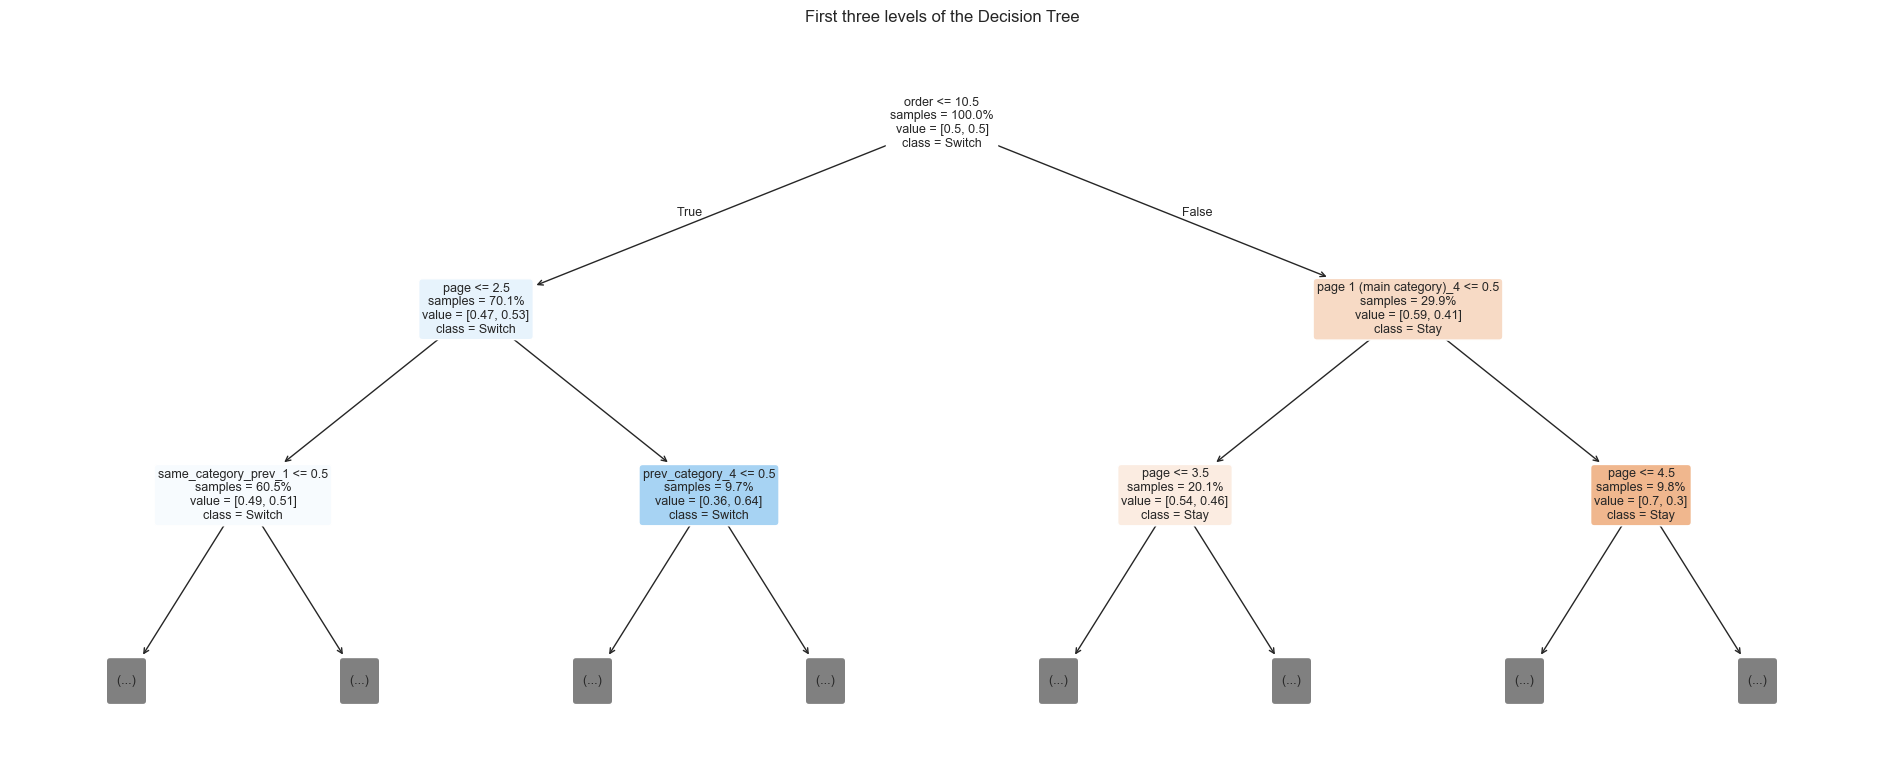

In [66]:
tree_feature_names = tree.named_steps["preprocess"].get_feature_names_out()
tree_feature_names = [name.replace("cat__", "").replace("num__", "")
                      for name in tree_feature_names]
plt.figure(figsize=(19, 8))
plot_tree(
    tree.named_steps["model"], max_depth=2, feature_names=tree_feature_names,
    class_names=["Stay", "Switch"], filled=True, rounded=True,
    proportion=True, impurity=False, precision=2, fontsize=9
)
plt.title("First three levels of the Decision Tree")
plt.tight_layout()
plt.show()

The first split separates clicks 1-10 from later clicks. Earlier clicks on catalogue
pages 3-5 favor Switch; later clicks favor Stay overall.

Follow true conditions left and false conditions right. `prev_category_4 = 1` means
the previous category is Sale. Node values are **weighted** proportions [Stay, Switch],
not observed rates. These are early splits; `(...)` hides the lower prediction branches.

### Random Forest
A Random Forest averages many trees. Both feature sets use the same 100 trees,
maximum depth 10, and minimum 50 rows per leaf. `balanced_subsample` weights classes
within each tree's random training sample. Only the input feature set changes.

#### Current information

In [67]:
current_forest_preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), current_categorical),
    ("num", "passthrough", current_numerical)
])
current_forest = Pipeline([
    ("preprocess", current_forest_preprocess),
    ("model", RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_leaf=50,
        class_weight="balanced_subsample", random_state=42, n_jobs=-1
    ))
])
current_forest.fit(X_train_current, y_train)
current_forest_pred = current_forest.predict(X_test_current)
current_forest_score = current_forest.predict_proba(X_test_current)[:, 1]

In [68]:
current_forest_result = evaluate(
    "Random Forest + Current", "Current", y_test, current_forest_pred, current_forest_score
)
results.append(current_forest_result)
display(pd.DataFrame([current_forest_result]).round(4))

,Model,Features,Accuracy,Switch precision,Switch recall,Switch F1,Macro F1,ROC-AUC
0,Random Forest + Current,Current,0.5946,0.2525,0.6216,0.3591,0.5313,0.6521


With Current features, Random Forest achieves Switch F1 0.3591,
precision 25.25%, and recall 62.16%.
This is the reference for testing history with the same algorithm and settings.

#### Current + History
Keep all Random Forest settings and preprocessing rules unchanged.

In [69]:
forest_preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), history_categorical),
    ("num", "passthrough", history_numerical)
])
forest = Pipeline([
    ("preprocess", forest_preprocess),
    ("model", RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_leaf=50,
        class_weight="balanced_subsample", random_state=42, n_jobs=-1
    ))
])
forest.fit(X_train_history, y_train)
forest_pred = forest.predict(X_test_history)
forest_score = forest.predict_proba(X_test_history)[:, 1]

In [70]:
forest_result = evaluate(
    "Random Forest + Current + History", "Current + History", y_test, forest_pred, forest_score
)
results.append(forest_result)
display(pd.DataFrame([current_forest_result, forest_result]).round(4))
forest_f1_change = forest_result["Switch F1"] - current_forest_result["Switch F1"]
print(f"Switch F1 change from history: {100 * forest_f1_change:+.2f} percentage points")

,Model,Features,Accuracy,Switch precision,Switch recall,Switch F1,Macro F1,ROC-AUC
0,Random Forest + Current,Current,0.5946,0.2525,0.6216,0.3591,0.5313,0.6521
1,Random Forest + Current + History,Current + History,0.6045,0.2599,0.6303,0.3680,0.5401,0.6606


Switch F1 change from history: +0.89 percentage points


Adding history raises Random Forest Switch F1 from 0.3591
to 0.3680, a small increase of **0.89 percentage points**.
Precision rises from 25.25% to 25.99%,
and recall from 62.16% to 63.03%.
History adds limited test performance here; it does not produce a large improvement.

## 15. Compare test performance
Compare the same six metrics for every approach. Switch F1 takes priority over accuracy.
The table is sorted by Switch F1; ties use the displayed model order.

In [71]:
comparison = pd.DataFrame(results)
display(comparison.sort_values("Switch F1", ascending=False, kind="stable").round(4))
best_row = comparison.loc[comparison["Switch F1"].idxmax()]
print("Highest observed test Switch F1:", best_row["Model"])

,Model,Features,Accuracy,Switch precision,Switch recall,Switch F1,Macro F1,ROC-AUC
6,Random Forest + Current + History,Current + History,0.6045,0.2599,0.6303,0.3680,0.5401,0.6606
5,Random Forest + Current,Current,0.5946,0.2525,0.6216,0.3591,0.5313,0.6521
3,Balanced Logistic + History,Current + History,0.5621,0.2335,0.6116,0.3379,0.5054,0.6242
2,Balanced Logistic Regression,Current,0.5664,0.2324,0.5961,0.3344,0.5064,0.6162
4,Decision Tree + History,Current + History,0.4869,0.2185,0.7019,0.3333,0.4582,0.6137
0,Always stay,None,0.8173,0.0000,0.0000,0.0000,0.4497,0.5000
1,Logistic Regression,Current,0.8173,0.0000,0.0000,0.0000,0.4497,0.6159


Highest observed test Switch F1: Random Forest + Current + History


Random Forest with Current + History has the highest observed Switch F1
(0.3680) and ROC-AUC (0.6606). Its accuracy (60.45%)
is below Always Stay, but it detects switches. Both matched model comparisons show
small gains from history; the improvement is larger for Random Forest.

### Confusion matrices
Rows are actual outcomes; columns are predicted outcomes. The bottom-left cell
contains missed switches. The top-right cell contains false switch alerts.

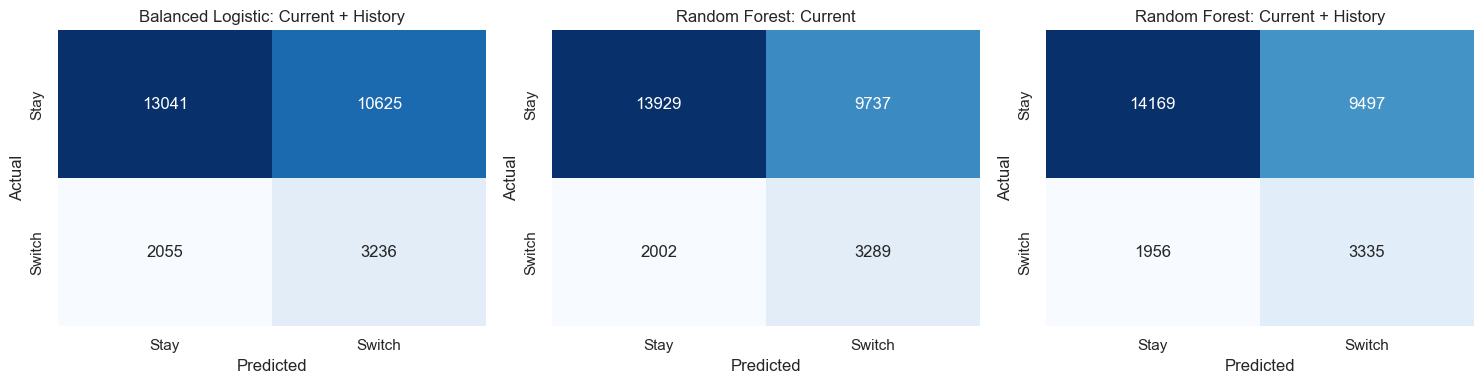

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, prediction, title in zip(
    axes, [history_pred, current_forest_pred, forest_pred],
    ["Balanced Logistic: Current + History", "Random Forest: Current", "Random Forest: Current + History"]
):
    sns.heatmap(confusion_matrix(y_test, prediction), annot=True, fmt="d", cbar=False,
                cmap="Blues", xticklabels=["Stay", "Switch"], yticklabels=["Stay", "Switch"], ax=ax)
    ax.set(title=title, xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
plt.show()

Adding history to Random Forest detects 46 more actual switches
and reduces false switch alerts by 240. Even so, the history model still
produces 9,497 false alerts. The improvement is useful to observe but remains limited.

### Selected candidate
Select by observed test Switch F1. Comparing models on this test set makes the choice
exploratory; confirm the winner on fresh sessions before using it in practice.

              precision    recall  f1-score   support

        Stay       0.88      0.60      0.71     23666
      Switch       0.26      0.63      0.37      5291

    accuracy                           0.60     28957
   macro avg       0.57      0.61      0.54     28957
weighted avg       0.77      0.60      0.65     28957



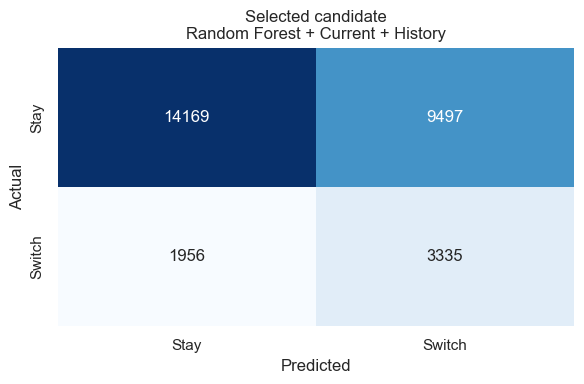

In [73]:
model_names = comparison["Model"].tolist()
test_predictions = [
    stay_pred, lr_pred, balanced_pred, history_pred, tree_pred, current_forest_pred, forest_pred
]
selected_index = model_names.index(best_row["Model"])
selected_pred = test_predictions[selected_index]
print(classification_report(y_test, selected_pred, target_names=["Stay", "Switch"], zero_division=0))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, selected_pred), annot=True, fmt="d", cbar=False,
            cmap="Blues", xticklabels=["Stay", "Switch"], yticklabels=["Stay", "Switch"])
plt.title(f"Selected candidate\n{best_row['Model']}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

For the selected Random Forest:

- **True negatives:** 14,169 Stay observations correctly predicted as Stay.
- **False positives:** 9,497 Stay observations incorrectly flagged as Switch.
- **False negatives:** 1,956 actual switches missed.
- **True positives:** 3,335 actual switches detected.

It detects **3,335 of 5,291 switches (63.03% recall)**.
Only **3,335 of 12,832 switch alerts are correct (25.99% precision)**.
The high false-positive count means this model is not deployment-ready.

## 16. Which features does the final Random Forest use?
Interpret the Random Forest with higher test Switch F1. Sum the importance of
one-hot columns back to their original features using the fitted encoder's order.

In [74]:
if forest_result["Switch F1"] >= current_forest_result["Switch F1"]:
    importance_model, importance_name = forest, "Random Forest: Current + History"
    importance_categorical, importance_numerical = history_categorical, history_numerical
else:
    importance_model, importance_name = current_forest, "Random Forest: Current"
    importance_categorical, importance_numerical = current_categorical, current_numerical

encoder = importance_model.named_steps["preprocess"].named_transformers_["cat"]
original_names = []
for feature, categories in zip(importance_categorical, encoder.categories_):
    original_names.extend([feature] * len(categories))
original_names.extend(importance_numerical)

importance = pd.Series(
    importance_model.named_steps["model"].feature_importances_, index=original_names
).groupby(level=0).sum().sort_values(ascending=False)
display(importance.rename("Importance").to_frame().round(4))

,Importance
order,0.1711
page,0.1647
colour,0.1169
prev_category,0.1129
category_visit_count,0.1113
page 1 (main category),0.0925
price,0.0744
location,0.0743
same_category_prev,0.0554
model photography,0.0266


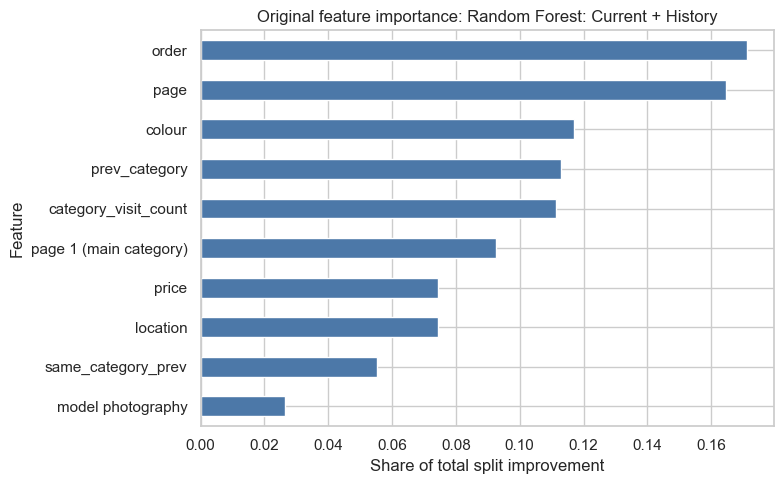

In [75]:
ax = importance.sort_values().plot.barh(figsize=(8, 5), color="#4c78a8")
ax.set(title=f"Original feature importance: {importance_name}",
       xlabel="Share of total split improvement", ylabel="Feature")
plt.tight_layout()
plt.show()

`order` (17.1%) and `page` (16.5%) have the largest
importance shares. Current category contributes 9.2%;
`prev_category`, `category_visit_count`, and `same_category_prev` contribute
11.3%, 11.1%, and 5.5%.
The trees use history, but the controlled test comparison shows only a small added benefit.

Impurity-based importance measures how much a variable helps separate classes at
training splits. It shows which variables the fitted trees use, **not whether those
variables improve test performance**, and may favor variables with more possible splits.
The direct Current versus Current + History test comparison is the main evidence for
history's added value. Importance is supporting interpretation only.

## 17. Conclusions and research answers

### 1. Is the Always-Stay baseline sufficient?
No. Accuracy is 81.73%, but Switch recall and F1 are both zero.
It cannot detect category switching.

### 2. Does handling class imbalance help?
Yes, for switch detection. Balancing Logistic Regression raises recall from
0.00% to 59.61% and F1 from 0.0000 to
0.3344. Accuracy falls to 56.64%, while precision is
only 23.24%: better detection comes with many false alerts.

**RQ1:** Current information provides a modest signal. The Current-only Random Forest
achieves F1 0.3591, precision 25.25%,
and recall 62.16%.

### 3. Does browsing history improve prediction? (RQ2)

| Controlled comparison | Current Switch F1 | Current + History Switch F1 | Change (percentage points) |
| --- | ---: | ---: | ---: |
| Balanced Logistic Regression | 0.3344 | 0.3379 | +0.35 |
| Random Forest | 0.3591 | 0.3680 | +0.89 |

History provides **limited incremental improvement** in both comparisons. The Random
Forest gain is larger, but still small. One split without uncertainty estimates does
not establish that these differences will persist on new sessions.

### 4. Which model performs best for detecting Switch?
Random Forest with Current + History has the highest observed Switch F1 (0.3680).
Its recall is 63.03%, precision 25.99%, and accuracy
60.45%. The Decision Tree has higher recall (70.19%) but lower
precision (21.85%) and F1 (0.3333). The forest offers the best
F1 balance tested here, but most switch alerts are still wrong. Confirm it on fresh
sessions before considering practical use.

## 18. Business interpretation
- Low predicted switch probability could support prioritizing the current category.
- High predicted switch probability could support introducing other categories.

This is a **behavioral prediction model that could support category-level recommendation
decisions**. It does not identify the destination category, recommend a specific product,
or predict session exit. It is not a complete recommendation system.

Class weighting can distort probability estimates, so check whether predicted probabilities
match observed switch rates before using them for decisions. The results do not establish
an increase in purchases or revenue.

## 19. Limitations
- Switch is a minority class; many predicted switches are false alerts.
- User-level preference information is limited, with no purchase, cart, rating, or explicit preference signals.
- The target is Stay versus Switch, not the destination category or session exit.
- Single-click sessions have no next click and cannot contribute a target observation.
- One session split does not establish performance on new people or future dates; confirm the selected model on fresh sessions.
- Data from 2008 may not represent modern e-commerce behavior.

## 20. Final checks
Check valid targets, required inputs, and identical Random Forest settings.
Session separation and first/last-click handling were checked when creating the data.

In [76]:
assert df_model["next_category"].notna().all()
assert df_model["switch_category"].isin([0, 1]).all()
assert set(current_history_features).issubset(df_model.columns)
assert current_forest.named_steps["model"].get_params() == forest.named_steps["model"].get_params()
print("Valid targets and inputs; identical Random Forest settings.")

Valid targets and inputs; identical Random Forest settings.


### Dataset reference
Variable meanings follow the local `e-shop clothing 2008 data description.txt`.
Its suggested citation is: Łapczyński, M. and Białowąs, S. (2013),
*Discovering Patterns of Users' Behaviour in an E-shop - Comparison of Consumer
Buying Behaviours in Poland and Other European Countries*, Studia Ekonomiczne,
151, pp. 144-153.